# 05 Cluster Profiling and Interpretation

## Objective

This notebook profiles the k = 4 customer clusters created in the clustering pipeline. The goal is to evaluate whether the clusters are meaningfully different across demographics, spending, purchasing, household structure, recency, campaign acceptance, and recent response.

This notebook does not retrain clustering, build supervised models, create a supervised target variable, remove outliers, or overwrite the clustered dataset. The `response` column is used only as an outcome-like profiling variable, not as a clustering input.

## Setup

Load the clustered dataset and prepare output locations for summary tables and profiling figures.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "customer_clustered.csv"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = REPORTS_DIR / "figures"
SUMMARY_PATH = REPORTS_DIR / "cluster_profile_summary.csv"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 150)

df = pd.read_csv(DATA_PATH, parse_dates=["dt_customer"])

print(f"Clustered data path: {DATA_PATH}")
print(f"Summary output path: {SUMMARY_PATH}")

Clustered data path: /Users/arjun/Documents/Intro DS final/data/processed/customer_clustered.csv
Summary output path: /Users/arjun/Documents/Intro DS final/reports/cluster_profile_summary.csv


## 1. Load and Inspect Clustered Data

Confirm that the clustered dataset has the expected shape, no missing or infinite values, and a valid `cluster` column.

In [2]:
numeric_df = df.select_dtypes(include=[np.number])
missing_total = int(df.isna().sum().sum())
infinite_total = int(np.isinf(numeric_df.to_numpy()).sum())

print(f"Dataset shape: {df.shape}")
print(f"Cluster column exists: {'cluster' in df.columns}")
print(f"Missing values: {missing_total}")
print(f"Infinite numeric values: {infinite_total}")
print(f"Clusters present: {sorted(df['cluster'].unique())}")

assert "cluster" in df.columns
assert missing_total == 0
assert infinite_total == 0

display(df.head())

Dataset shape: (2213, 54)
Cluster column exists: True
Missing values: 0
Infinite numeric values: 0
Clusters present: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


,id,year_birth,education,marital_status,income,kidhome,teenhome,dt_customer,recency,mnt_wines,mnt_fruits,mnt_meat_products,mnt_fish_products,mnt_sweet_products,mnt_gold_prods,num_deals_purchases,num_web_purchases,num_catalog_purchases,num_store_purchases,num_web_visits_month,accepted_cmp3,accepted_cmp4,accepted_cmp5,accepted_cmp1,accepted_cmp2,complain,z_cost_contact,z_revenue,response,age,customer_tenure_days,customer_tenure_years,children_total,has_children,household_size,total_spending,wine_share,fruits_share,meat_share,fish_share,sweets_share,gold_share,luxury_spending_ratio,spending_per_tenure_year,total_store_web_catalog_purchases,total_purchases,web_purchase_share,store_purchase_share,catalog_purchase_share,deal_purchase_share,average_spend_per_purchase,total_campaign_acceptances,any_campaign_acceptance,cluster
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,57,663,1.815195,0,0,1,1617,0.392703,0.054422,0.337662,0.106370,0.054422,0.054422,0.447124,890.813348,22,25,0.363636,0.181818,0.454545,0.120000,73.500000,0,0,0
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,60,113,0.309377,2,1,3,27,0.407407,0.037037,0.222222,0.074074,0.037037,0.222222,0.629630,87.272124,4,6,0.250000,0.500000,0.250000,0.333333,6.750000,0,0,3
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,49,312,0.854209,0,0,2,776,0.548969,0.063144,0.163660,0.143041,0.027062,0.054124,0.603093,908.442308,20,21,0.400000,0.500000,0.100000,0.047619,38.800000,0,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,30,139,0.380561,1,1,3,53,0.207547,0.075472,0.377358,0.188679,0.056604,0.094340,0.301887,139.267986,6,8,0.333333,0.666667,0.000000,0.250000,8.833333,0,0,1
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,33,161,0.440794,1,1,3,422,0.409953,0.101896,0.279621,0.109005,0.063981,0.035545,0.445498,957.363354,14,19,0.357143,0.428571,0.214286,0.263158,30.142857,0,0,0


In [3]:
cluster_counts = df["cluster"].value_counts().sort_index()
cluster_pct = (cluster_counts / len(df) * 100).round(2)
cluster_size_table = pd.DataFrame({
    "cluster_size": cluster_counts,
    "cluster_pct": cluster_pct,
})
display(cluster_size_table)

,cluster_size,cluster_pct
cluster,,
0,667,30.14
1,413,18.66
2,640,28.92
3,493,22.28


## 2. Numeric Cluster Profiles

The tables below summarize the main profiling variables by cluster. Mean values show direction and magnitude; medians help check whether extreme values are driving the story.

In [4]:
profile_vars = [
    "age",
    "income",
    "children_total",
    "household_size",
    "recency",
    "total_spending",
    "spending_per_tenure_year",
    "total_purchases",
    "average_spend_per_purchase",
    "luxury_spending_ratio",
    "total_campaign_acceptances",
    "any_campaign_acceptance",
    "response",
]

cluster_means = df.groupby("cluster")[profile_vars].mean()
cluster_medians = df.groupby("cluster")[profile_vars].median()
cluster_stds = df.groupby("cluster")[profile_vars].std()

print("Cluster means")
display(cluster_means.round(3))

print("Cluster medians")
display(cluster_medians.round(3))

print("Cluster standard deviations")
display(cluster_stds.round(3))

Cluster means


,age,income,children_total,household_size,recency,total_spending,spending_per_tenure_year,total_purchases,average_spend_per_purchase,luxury_spending_ratio,total_campaign_acceptances,any_campaign_acceptance,response
cluster,,,,,,,,,,,,,
0,45.591,73046.552,0.286,1.879,49.367,1249.309,5233.677,20.520,67.178,0.477,0.588,0.349,0.250
1,38.184,29592.109,0.823,2.453,48.317,93.508,155.356,7.545,14.034,0.393,0.065,0.065,0.102
2,49.141,56451.181,1.202,2.892,47.969,678.673,1899.259,19.473,40.511,0.757,0.319,0.255,0.134
3,44.907,37580.544,1.617,3.290,50.448,75.213,301.480,7.475,12.810,0.641,0.075,0.071,0.077


Cluster medians


,age,income,children_total,household_size,recency,total_spending,spending_per_tenure_year,total_purchases,average_spend_per_purchase,luxury_spending_ratio,total_campaign_acceptances,any_campaign_acceptance,response
cluster,,,,,,,,,,,,,
0,45.0,73926.0,0.0,2.0,51.0,1213.0,1265.898,20.0,68.696,0.479,0.0,0.0,0.0
1,37.0,26224.0,1.0,2.0,49.0,60.0,74.024,7.0,11.667,0.395,0.0,0.0,0.0
2,49.0,56361.5,1.0,3.0,48.5,576.0,633.874,19.0,35.118,0.771,0.0,0.0,0.0
3,43.0,36921.0,2.0,3.0,50.0,54.0,90.613,7.0,11.000,0.640,0.0,0.0,0.0


Cluster standard deviations


,age,income,children_total,household_size,recency,total_spending,spending_per_tenure_year,total_purchases,average_spend_per_purchase,luxury_spending_ratio,total_campaign_acceptances,any_campaign_acceptance,response
cluster,,,,,,,,,,,,,
0,13.113,13872.053,0.472,0.672,29.205,488.779,24504.574,4.739,28.011,0.137,0.958,0.477,0.434
1,10.652,34654.503,0.553,0.731,29.358,104.241,293.376,3.466,11.432,0.121,0.247,0.247,0.303
2,9.904,11417.962,0.575,0.748,28.556,415.897,13720.312,5.819,20.250,0.124,0.617,0.436,0.341
3,9.927,12606.045,0.632,0.770,28.749,64.425,1392.352,3.064,9.335,0.154,0.279,0.257,0.267


## 3. Categorical Breakdowns

Education, marital status, and children indicators help explain whether clusters differ by household structure and demographic composition.

In [5]:
education_breakdown = pd.crosstab(df["cluster"], df["education"], normalize="index").mul(100).round(1)
marital_breakdown = pd.crosstab(df["cluster"], df["marital_status"], normalize="index").mul(100).round(1)
children_breakdown = pd.crosstab(df["cluster"], df["has_children"], normalize="index").mul(100).round(1)
children_breakdown = children_breakdown.rename(columns={0: "no_children_pct", 1: "has_children_pct"})

print("Education distribution by cluster (%)")
display(education_breakdown)

print("Marital status distribution by cluster (%)")
display(marital_breakdown)

print("Has children distribution by cluster (%)")
display(children_breakdown)

Education distribution by cluster (%)


education,2n Cycle,Basic,Graduation,Master,PhD
cluster,,,,,
0,8.8,0.0,57.7,14.1,19.3
1,19.6,13.1,56.7,8.2,2.4
2,4.1,0.0,43.6,20.9,31.4
3,6.5,0.0,44.2,20.9,28.4


Marital status distribution by cluster (%)


marital_status,Absurd,Alone,Divorced,Married,Single,Together,Widow,YOLO
cluster,,,,,,,,
0,0.3,0.0,10.2,34.6,25.8,24.6,4.5,0.0
1,0.0,0.2,8.7,40.9,26.2,22.0,1.9,0.0
2,0.0,0.2,11.9,41.9,14.7,27.2,3.9,0.3
3,0.0,0.2,10.3,38.3,19.5,29.0,2.6,0.0


Has children distribution by cluster (%)


has_children,no_children_pct,has_children_pct
cluster,,
0,72.3,27.7
1,25.7,74.3
2,6.2,93.8
3,0.8,99.2


## 4. Compare Clusters Against Global Averages

The table below compares cluster means with the overall dataset average. Positive values mean the cluster is above the overall average; negative values mean it is below average.

In [6]:
comparison_vars = [
    "age",
    "income",
    "children_total",
    "household_size",
    "recency",
    "total_spending",
    "total_purchases",
    "average_spend_per_purchase",
    "luxury_spending_ratio",
    "total_campaign_acceptances",
    "response",
]

global_means = df[comparison_vars].mean()
cluster_mean_comparison = df.groupby("cluster")[comparison_vars].mean()
relative_diff_pct = ((cluster_mean_comparison - global_means) / global_means * 100).round(1)

print("Cluster mean values")
display(cluster_mean_comparison.round(3))

print("Relative difference from global mean (%)")
display(relative_diff_pct)

Cluster mean values


,age,income,children_total,household_size,recency,total_spending,total_purchases,average_spend_per_purchase,luxury_spending_ratio,total_campaign_acceptances,response
cluster,,,,,,,,,,,
0,45.591,73046.552,0.286,1.879,49.367,1249.309,20.520,67.178,0.477,0.588,0.250
1,38.184,29592.109,0.823,2.453,48.317,93.508,7.545,14.034,0.393,0.065,0.102
2,49.141,56451.181,1.202,2.892,47.969,678.673,19.473,40.511,0.757,0.319,0.134
3,44.907,37580.544,1.617,3.290,50.448,75.213,7.475,12.810,0.641,0.075,0.077


Relative difference from global mean (%)


,age,income,children_total,household_size,recency,total_spending,total_purchases,average_spend_per_purchase,luxury_spending_ratio,total_campaign_acceptances,response
cluster,,,,,,,,,,,
0,1.1,39.8,-69.8,-27.6,0.7,105.8,37.8,79.4,-17.5,97.1,66.4
1,-15.3,-43.3,-13.1,-5.4,-1.4,-84.6,-49.3,-62.5,-32.1,-78.1,-32.4
2,9.0,8.1,26.8,11.5,-2.1,11.8,30.8,8.2,30.7,6.9,-10.7
3,-0.4,-28.1,70.6,26.9,2.9,-87.6,-49.8,-65.8,10.8,-74.8,-48.8


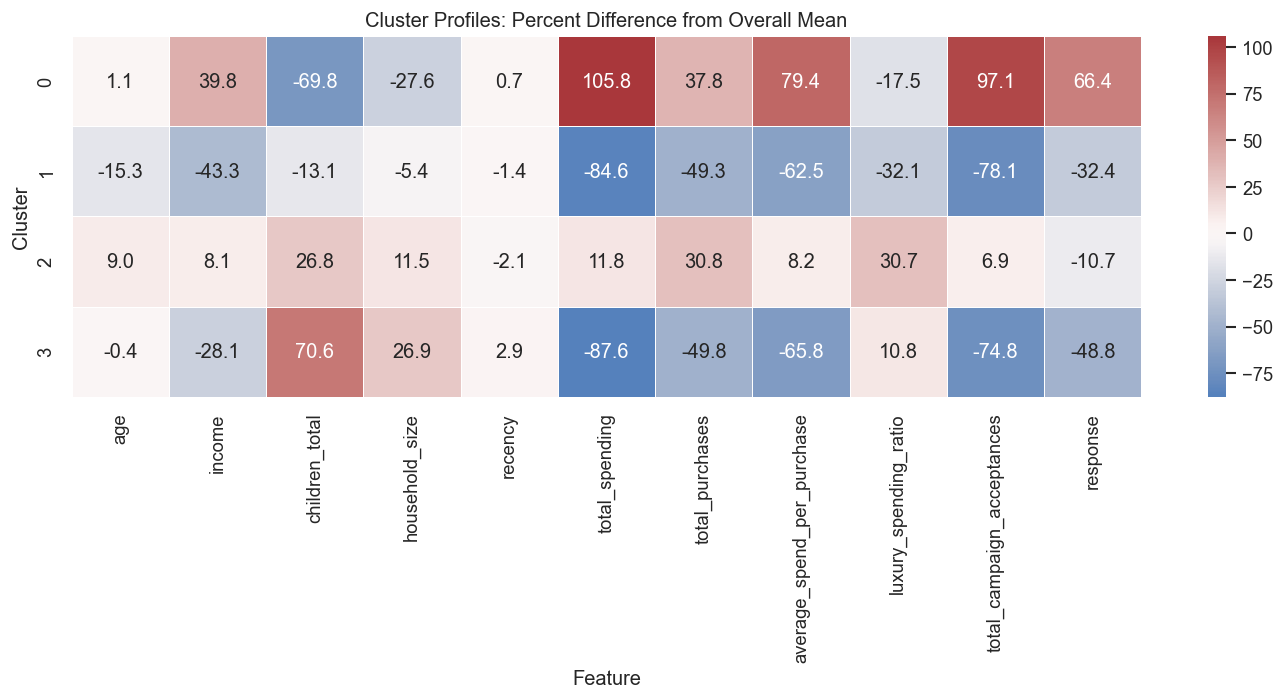

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(relative_diff_pct, cmap="vlag", center=0, annot=True, fmt=".1f", linewidths=0.4, ax=ax)
ax.set_title("Cluster Profiles: Percent Difference from Overall Mean")
ax.set_xlabel("Feature")
ax.set_ylabel("Cluster")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "cluster_profile_relative_heatmap.png", bbox_inches="tight")
plt.show()

## 5. Visualize Cluster Differences

These plots compare cluster sizes and important demographic, spending, purchase, and campaign variables.

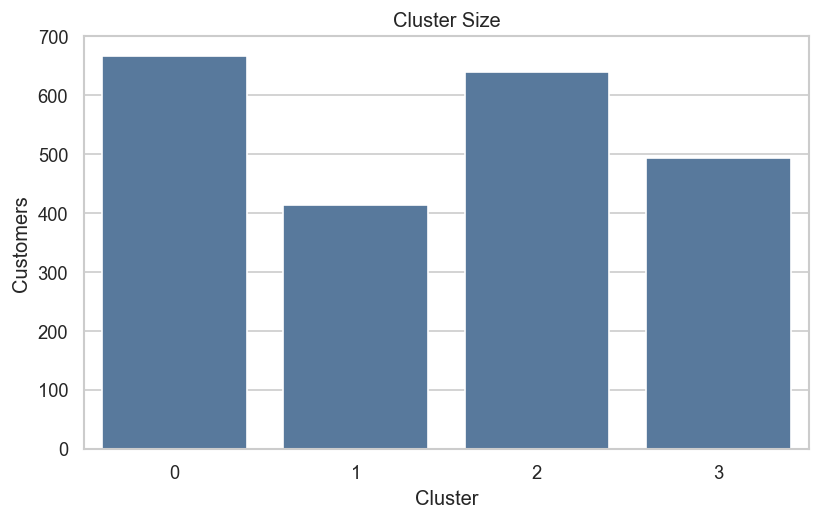

In [8]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(x=cluster_size_table.index.astype(str), y=cluster_size_table["cluster_size"], ax=ax, color="#4C78A8")
ax.set_title("Cluster Size")
ax.set_xlabel("Cluster")
ax.set_ylabel("Customers")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "cluster_profile_sizes.png", bbox_inches="tight")
plt.show()

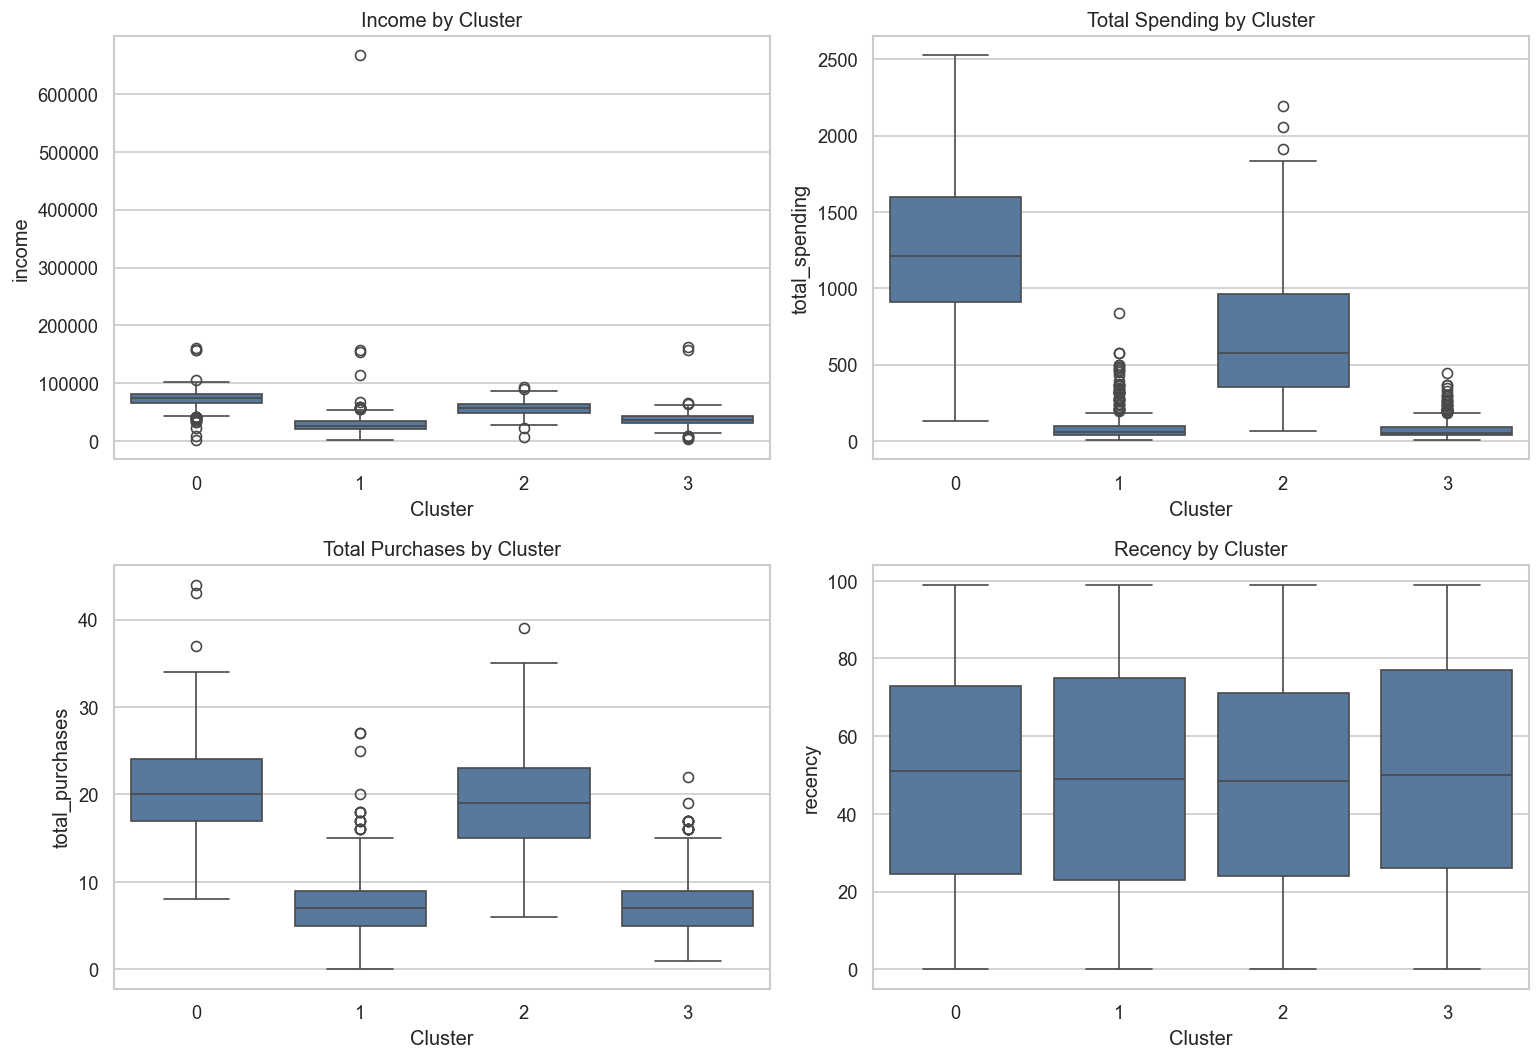

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
box_vars = [
    ("income", "Income by Cluster"),
    ("total_spending", "Total Spending by Cluster"),
    ("total_purchases", "Total Purchases by Cluster"),
    ("recency", "Recency by Cluster"),
]

for ax, (column, title) in zip(axes.ravel(), box_vars):
    sns.boxplot(data=df, x="cluster", y=column, ax=ax, color="#4C78A8")
    ax.set_title(title)
    ax.set_xlabel("Cluster")
    ax.set_ylabel(column)

fig.tight_layout()
fig.savefig(FIGURE_DIR / "cluster_profile_core_boxplots.png", bbox_inches="tight")
plt.show()

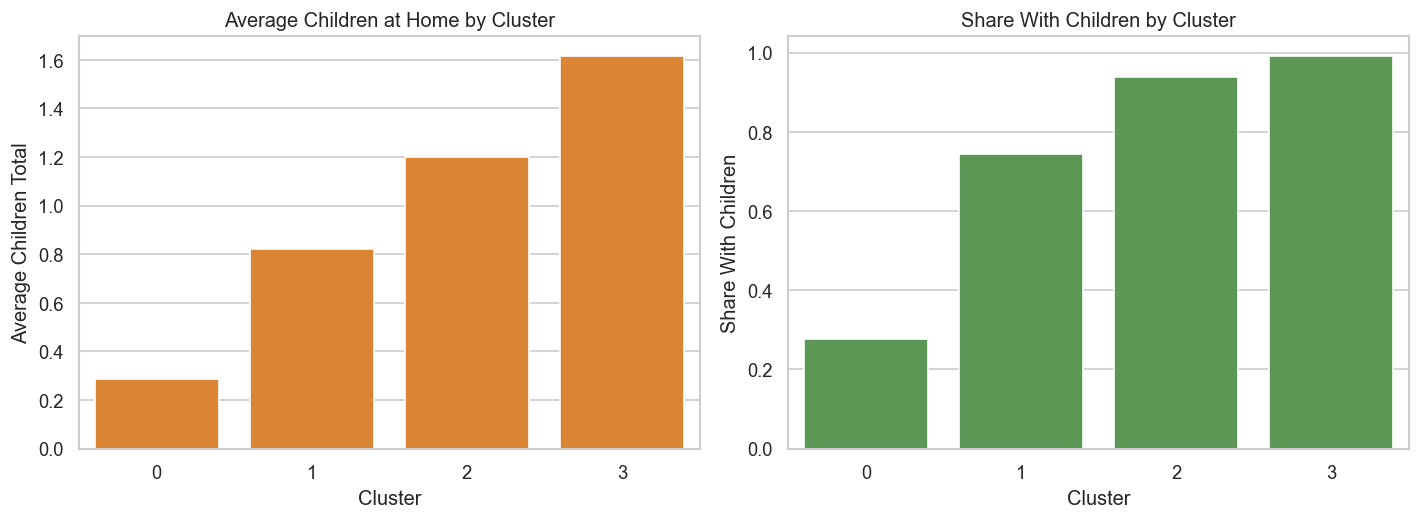

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.barplot(data=df, x="cluster", y="children_total", estimator="mean", errorbar=None, ax=axes[0], color="#F58518")
axes[0].set_title("Average Children at Home by Cluster")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Average Children Total")

sns.barplot(data=df, x="cluster", y="has_children", estimator="mean", errorbar=None, ax=axes[1], color="#54A24B")
axes[1].set_title("Share With Children by Cluster")
axes[1].set_xlabel("Cluster")
axes[1].set_ylabel("Share With Children")

fig.tight_layout()
fig.savefig(FIGURE_DIR / "cluster_profile_children.png", bbox_inches="tight")
plt.show()

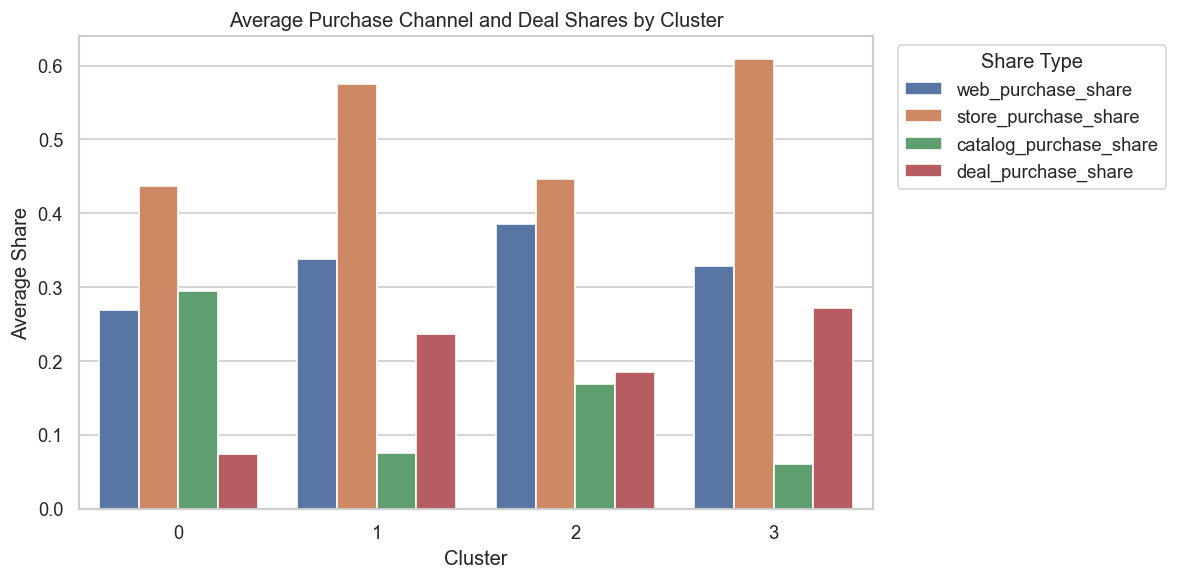

In [11]:
channel_share_cols = [
    "web_purchase_share",
    "store_purchase_share",
    "catalog_purchase_share",
    "deal_purchase_share",
]
channel_means = df.groupby("cluster")[channel_share_cols].mean().reset_index()
channel_long = channel_means.melt(id_vars="cluster", var_name="purchase_share", value_name="mean_share")

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=channel_long, x="cluster", y="mean_share", hue="purchase_share", ax=ax)
ax.set_title("Average Purchase Channel and Deal Shares by Cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Average Share")
ax.legend(title="Share Type", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "cluster_profile_purchase_channels.png", bbox_inches="tight")
plt.show()

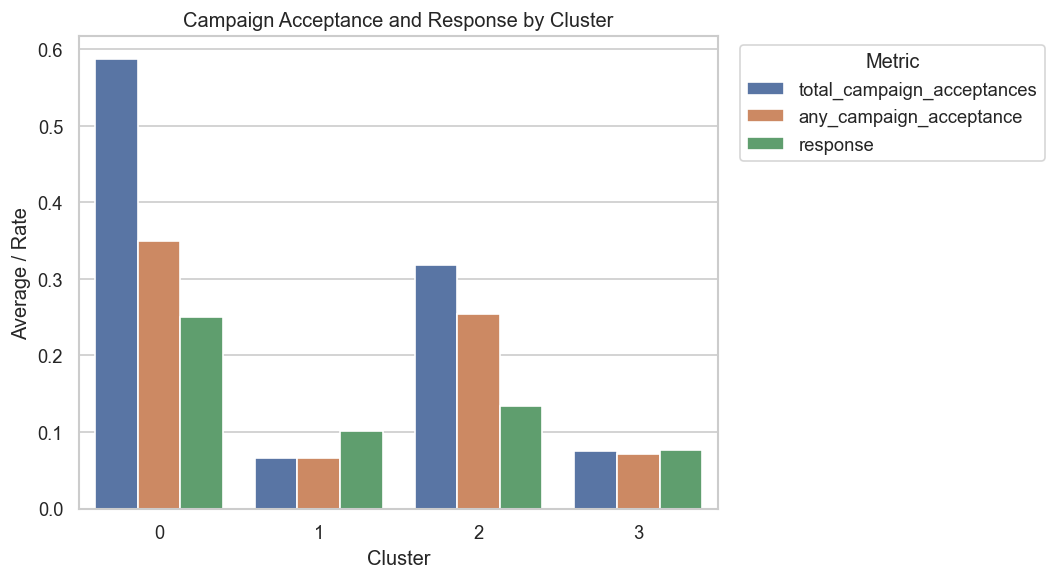

In [12]:
campaign_means = df.groupby("cluster")[
    ["total_campaign_acceptances", "any_campaign_acceptance", "response"]
].mean().reset_index()
campaign_long = campaign_means.melt(id_vars="cluster", var_name="campaign_metric", value_name="mean_value")

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=campaign_long, x="cluster", y="mean_value", hue="campaign_metric", ax=ax)
ax.set_title("Campaign Acceptance and Response by Cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Average / Rate")
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "cluster_profile_campaign_response.png", bbox_inches="tight")
plt.show()

## 6. Segment Descriptions

These names are tentative and based on observed profile differences. They should be treated as working labels for the final project, not permanent business categories.

In [13]:
segment_metadata = {
    0: {
        "proposed_segment_name": "Affluent High-Spend Catalog Customers",
        "key_interpretation": "Highest income and spending, strong catalog purchasing, fewest children, highest campaign acceptance and response rate.",
    },
    1: {
        "proposed_segment_name": "Younger Low-Spend Budget Customers",
        "key_interpretation": "Youngest cluster with lowest median income, low spending and purchases, moderate child presence, and low campaign engagement.",
    },
    2: {
        "proposed_segment_name": "Established Family Wine-Oriented Shoppers",
        "key_interpretation": "Older family-heavy customers with moderate-high income, strong purchase volume, high wine/luxury spending mix, and moderate campaign engagement.",
    },
    3: {
        "proposed_segment_name": "Large-Household Low-Spend Store Shoppers",
        "key_interpretation": "Largest households and most children, low spending and purchases, strongest store/deal orientation, and lowest response rate.",
    },
}

for cluster_id in sorted(segment_metadata):
    subset = df[df["cluster"] == cluster_id]
    size = len(subset)
    pct = size / len(df) * 100
    meta = segment_metadata[cluster_id]
    print(f"Cluster {cluster_id}: {meta['proposed_segment_name']}")
    print(f"Size: {size} customers ({pct:.2f}%)")
    print(meta["key_interpretation"])
    print(
        "Observed means: "
        f"income=${subset['income'].mean():,.0f}, "
        f"total spending={subset['total_spending'].mean():,.0f}, "
        f"total purchases={subset['total_purchases'].mean():.1f}, "
        f"children={subset['children_total'].mean():.2f}, "
        f"response rate={subset['response'].mean():.1%}"
    )
    print("-" * 100)

Cluster 0: Affluent High-Spend Catalog Customers
Size: 667 customers (30.14%)
Highest income and spending, strong catalog purchasing, fewest children, highest campaign acceptance and response rate.
Observed means: income=$73,047, total spending=1,249, total purchases=20.5, children=0.29, response rate=25.0%
----------------------------------------------------------------------------------------------------
Cluster 1: Younger Low-Spend Budget Customers
Size: 413 customers (18.66%)
Youngest cluster with lowest median income, low spending and purchases, moderate child presence, and low campaign engagement.
Observed means: income=$29,592, total spending=94, total purchases=7.5, children=0.82, response rate=10.2%
----------------------------------------------------------------------------------------------------
Cluster 2: Established Family Wine-Oriented Shoppers
Size: 640 customers (28.92%)
Older family-heavy customers with moderate-high income, strong purchase volume, high wine/luxury sp

### Cluster 0: Affluent High-Spend Catalog Customers

- **Size:** 667 customers, about 30% of the dataset.
- **Defining characteristics:** Highest average income, highest total spending, highest average spend per purchase, and fewest children at home.
- **Spending behavior:** Strongest total spending overall, with especially high wine, meat, fruit, fish, and sweet product spending.
- **Purchase channel behavior:** Highest catalog share and high store purchase count; low deal-purchase share.
- **Campaign/response behavior:** Highest historical campaign acceptance and highest recent response rate.
- **Possible marketing interpretation:** This looks like a high-value segment that may be receptive to premium offers and catalog-style outreach.

### Cluster 1: Younger Low-Spend Budget Customers

- **Size:** 413 customers, about 19% of the dataset.
- **Defining characteristics:** Youngest cluster with the lowest median income and low purchase activity.
- **Spending behavior:** Low total spending and low average spend per purchase.
- **Purchase channel behavior:** More store-oriented than catalog-oriented, with a moderate deal-purchase share.
- **Campaign/response behavior:** Low historical campaign acceptance and below-average recent response rate.
- **Possible marketing interpretation:** This group may need lower-risk, value-oriented offers, but the data does not show strong campaign engagement yet.

### Cluster 2: Established Family Wine-Oriented Shoppers

- **Size:** 640 customers, about 29% of the dataset.
- **Defining characteristics:** Oldest average age, family-heavy, moderate-high income, and high purchase count.
- **Spending behavior:** Above-average total spending with the strongest luxury/wine-oriented spending ratio.
- **Purchase channel behavior:** Highest web purchase share and substantial store activity; deal-purchase share is near average.
- **Campaign/response behavior:** Moderate historical campaign acceptance and slightly below-average response.
- **Possible marketing interpretation:** This segment may respond to product mix and convenience-oriented messaging more than broad campaign exposure alone.

### Cluster 3: Large-Household Low-Spend Store Shoppers

- **Size:** 493 customers, about 22% of the dataset.
- **Defining characteristics:** Largest households and highest children count, with lower income and very low spending.
- **Spending behavior:** Lowest total spending and lowest average spend per purchase.
- **Purchase channel behavior:** Strongest store and deal orientation; very low catalog share.
- **Campaign/response behavior:** Lowest recent response rate and low historical campaign acceptance.
- **Possible marketing interpretation:** This appears to be a value-sensitive household segment where store-based and deal-oriented behavior dominates.

## 7. Is k = 4 Meaningful?

**Are all four clusters distinct enough to interpret?**  
Yes, the four clusters show interpretable differences across income, spending, purchase channels, children/household structure, and campaign behavior.

**Are any clusters redundant or weakly separated?**  
Clusters 1 and 3 are both low-spend groups, so they are closer conceptually than the others. However, they are not redundant: cluster 3 has much larger households, more children, stronger store/deal orientation, and lower response, while cluster 1 is younger with smaller households and somewhat different education composition.

**Does k = 4 seem defensible after profiling?**  
Yes. k = 4 creates more actionable interpretation than a broad k = 2 split while still staying readable for a final project.

**Would k = 2 or k = 3 be simpler but less informative?**  
Yes. k = 2 would likely separate higher-value from lower-value customers, but it would hide the important distinction between low-spend younger/smaller-household customers and low-spend larger-household store/deal customers. k = 3 might be simpler but would likely merge one of those low-spend groups or blur the family-oriented moderate/high purchasing group.

**Recommendation:** Keep k = 4 for the final project, but describe the solution as a defensible segmentation rather than a perfect one. The next step should use these profiles carefully and avoid overclaiming.

## 8. Save Cluster Profile Summary

Save one concise row per cluster for use in the final report and later cluster interpretation step.

In [14]:
summary_rows = []
for cluster_id in sorted(df["cluster"].unique()):
    subset = df[df["cluster"] == cluster_id]
    meta = segment_metadata[cluster_id]
    summary_rows.append({
        "cluster": cluster_id,
        "cluster_size": len(subset),
        "cluster_pct": round(len(subset) / len(df) * 100, 2),
        "proposed_segment_name": meta["proposed_segment_name"],
        "avg_age": round(subset["age"].mean(), 2),
        "median_income": round(subset["income"].median(), 2),
        "avg_children_total": round(subset["children_total"].mean(), 2),
        "avg_recency": round(subset["recency"].mean(), 2),
        "avg_total_spending": round(subset["total_spending"].mean(), 2),
        "avg_total_purchases": round(subset["total_purchases"].mean(), 2),
        "avg_average_spend_per_purchase": round(subset["average_spend_per_purchase"].mean(), 2),
        "avg_total_campaign_acceptances": round(subset["total_campaign_acceptances"].mean(), 2),
        "response_rate": round(subset["response"].mean(), 4),
        "key_interpretation": meta["key_interpretation"],
    })

cluster_profile_summary = pd.DataFrame(summary_rows)
cluster_profile_summary.to_csv(SUMMARY_PATH, index=False)

display(cluster_profile_summary)
print(f"Saved cluster profile summary to: {SUMMARY_PATH}")

,cluster,cluster_size,cluster_pct,proposed_segment_name,avg_age,median_income,avg_children_total,avg_recency,avg_total_spending,avg_total_purchases,avg_average_spend_per_purchase,avg_total_campaign_acceptances,response_rate,key_interpretation
0,0,667,30.14,Affluent High-Spend Catalog Customers,45.59,73926.0,0.29,49.37,1249.31,20.52,67.18,0.59,0.2504,"Highest income and spending, strong catalog pu..."
1,1,413,18.66,Younger Low-Spend Budget Customers,38.18,26224.0,0.82,48.32,93.51,7.54,14.03,0.07,0.1017,"Youngest cluster with lowest median income, lo..."
2,2,640,28.92,Established Family Wine-Oriented Shoppers,49.14,56361.5,1.20,47.97,678.67,19.47,40.51,0.32,0.1344,Older family-heavy customers with moderate-hig...
3,3,493,22.28,Large-Household Low-Spend Store Shoppers,44.91,36921.0,1.62,50.45,75.21,7.47,12.81,0.08,0.0771,"Largest households and most children, low spen..."


Saved cluster profile summary to: /Users/arjun/Documents/Intro DS final/reports/cluster_profile_summary.csv


## 9. Final Validation

Confirm files and figures created by this profiling notebook.

In [15]:
saved_summary = pd.read_csv(SUMMARY_PATH)
saved_figures = sorted(path.name for path in FIGURE_DIR.glob("cluster_profile_*.png"))

print(f"Summary rows: {saved_summary.shape[0]}")
print(f"Summary columns: {saved_summary.shape[1]}")
print("Saved cluster profiling figures:")
for figure in saved_figures:
    print(f"- {figure}")

assert saved_summary.shape[0] == df["cluster"].nunique()
assert set(saved_summary["cluster"]) == set(df["cluster"].unique())

Summary rows: 4
Summary columns: 14
Saved cluster profiling figures:
- cluster_profile_campaign_response.png
- cluster_profile_children.png
- cluster_profile_core_boxplots.png
- cluster_profile_purchase_channels.png
- cluster_profile_relative_heatmap.png
- cluster_profile_sizes.png
